In [1]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading and exploring the dataset
df = pd.read_csv(r"C:\Users\user\Desktop\DATA WEB\diabetes.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget Distribution:")
print(df['diabetes'].value_counts(normalize=True))
print("\nData Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (100000, 9)

First 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Target Distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null C

In [3]:
# Data Preprocessing
# Encoding categorical variables
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

# Features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (80000, 8)
Test set shape: (20000, 8)


In [4]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    print(f"\n {model_name} Results")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if auc:
        print(f"AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

In [5]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")


 Logistic Regression Results
Accuracy: 0.9603
Precision: 0.8588
Recall: 0.6371
F1 Score: 0.7315
AUC: 0.9620

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [6]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf_results = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")


 Random Forest Results
Accuracy: 0.9704
Precision: 0.9453
Recall: 0.6912
F1 Score: 0.7985
AUC: 0.9667

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [7]:
# XGBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, n_estimators=400, eval_metric='logloss')
xgb_results = evaluate_model(xgb_model, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost")


 XGBoost Results
Accuracy: 0.9677
Precision: 0.8868
Recall: 0.7100
F1 Score: 0.7886
AUC: 0.9732

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.89      0.71      0.79      1700

    accuracy                           0.97     20000
   macro avg       0.93      0.85      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [9]:
!pip install lightgbm
from lightgbm import LGBMClassifier
# Creating the model
lgb_model = LGBMClassifier(random_state=42, n_estimators=400, verbose=-1)
lgb_results = evaluate_model(lgb_model, X_train_scaled, X_test_scaled, y_train, y_test, "LightGBM")

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 423.9 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.5 MB 423.9 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.5 MB 423.9 kB/s eta 0:00:03
   --------------------- ------------------ 0.8/1.5 MB 444.7 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 444.7 kB/s eta 0:00:02
   ---------------------------- ----------- 1.0/1.5 MB 502

In [11]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
svm_model = SVC(probability=True, random_state=42, kernel='rbf')
svm_results = evaluate_model(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "SVM")


 SVM Results
Accuracy: 0.9645
Precision: 0.9723
Recall: 0.5994
F1 Score: 0.7416
AUC: 0.9335

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.97      0.60      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [12]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results = evaluate_model(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "KNN")


 KNN Results
Accuracy: 0.9616
Precision: 0.8820
Recall: 0.6329
F1 Score: 0.7370
AUC: 0.9050

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.88      0.63      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



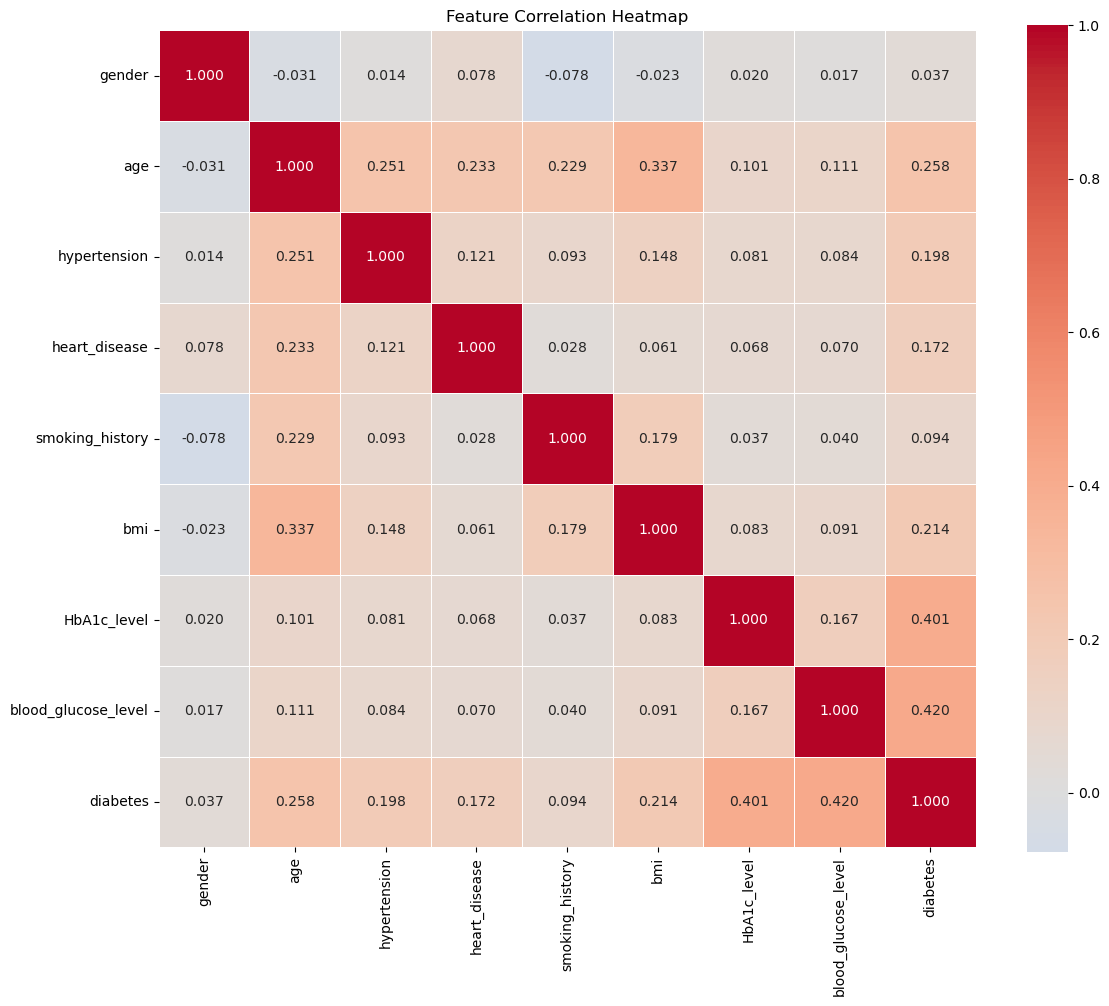

Correlation with Diabetes
diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
smoking_history        0.094290
gender                 0.037411
Name: diabetes, dtype: float64

Top 3 Features Most Correlated with Diabetes: ['blood_glucose_level', 'HbA1c_level', 'age']


In [13]:
# Correlation Heatmap and Feature Importance Analysis
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix['diabetes'].sort_values(ascending=False)
print("Correlation with Diabetes")
print(target_corr)

# Identify top 3 features by correlation with target
top_features = target_corr[1:4].index.tolist()  # Exclude diabetes itself
print(f"\nTop 3 Features Most Correlated with Diabetes: {top_features}")

XGBoost Feature Importance
               Feature  Importance
6          HbA1c_level    0.520019
7  blood_glucose_level    0.274287
3        heart_disease    0.053350
2         hypertension    0.044828
1                  age    0.035820
5                  bmi    0.024540
0               gender    0.023914
4      smoking_history    0.023241


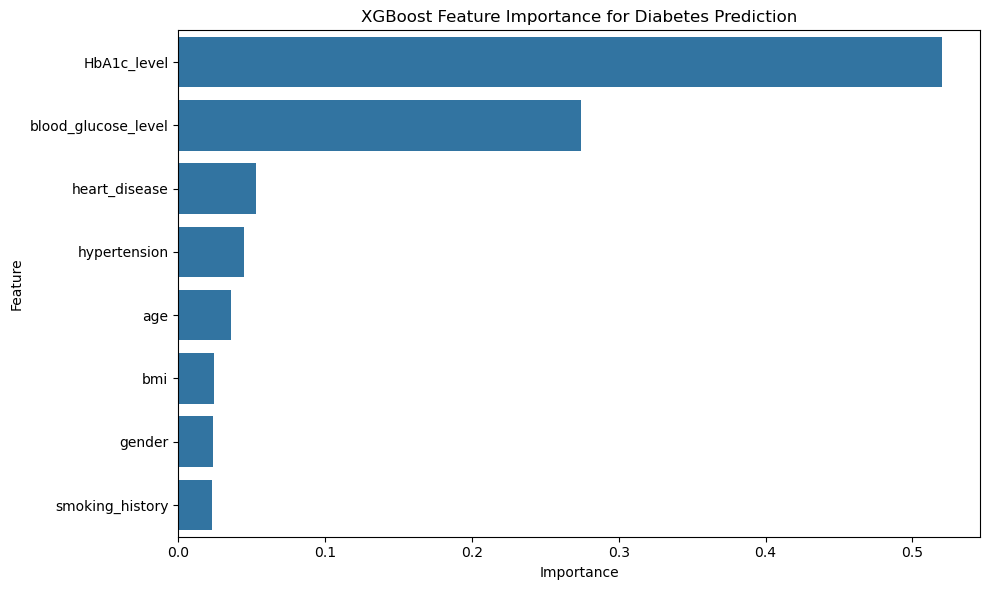

In [14]:
# Feature Importance from XGBoost
importances = xgb_model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("XGBoost Feature Importance")
print(feat_imp)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('XGBoost Feature Importance for Diabetes Prediction')
plt.tight_layout()
plt.show()

Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score     AUC
3             LightGBM    0.9700     0.9310  0.6982    0.7980  0.9774
2              XGBoost    0.9676     0.8868  0.7100    0.7886  0.9732
1        Random Forest    0.9704     0.9453  0.6912    0.7985  0.9667
0  Logistic Regression    0.9602     0.8588  0.6371    0.7315  0.9620
4                  SVM    0.9645     0.9723  0.5994    0.7416  0.9335
5                  KNN    0.9616     0.8820  0.6329    0.7370  0.9050


<Figure size 1200x600 with 0 Axes>

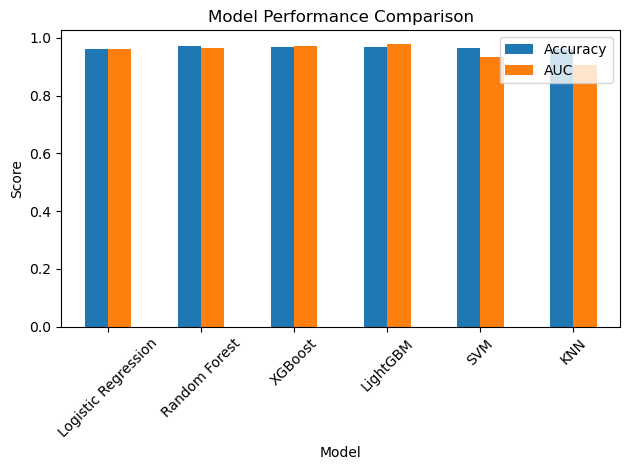

In [15]:
# Compare all models
results = [lr_results, rf_results, xgb_results, lgb_results, svm_results, knn_results]

comparison_df = pd.DataFrame({
    'Model': [r['model_name'] for r in results],
    'Accuracy': [r['accuracy'] for r in results],
    'Precision': [r['precision'] for r in results],
    'Recall': [r['recall'] for r in results],
    'F1 Score': [r['f1'] for r in results],
    'AUC': [r['auc'] for r in results]
})

print("Model Comparison")
print(comparison_df.sort_values('AUC', ascending=False).round(4))

# Visualize comparison
plt.figure(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy', 'AUC']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Diabetes Risk Factors from the Dataset 

Risk Factor Comparison (Diabetes vs Non-Diabetes):
            age           bmi        HbA1c_level        blood_glucose_level  \
           mean median   mean median        mean median                mean   
diabetes                                                                      
0         40.12   40.0  26.89  27.32        5.40    5.8              132.85   
1         60.95   62.0  31.99  29.97        6.93    6.6              194.09   

                hypertension heart_disease  
         median         mean          mean  
diabetes                                    
0         140.0         0.06          0.03  
1         160.0         0.25          0.15  
Major Risk Factors Identified:

1. HbA1c Level (Strongest)
2. Blood Glucose Level
3. Age
4. BMI (Obesity)
5. Hypertension
6. Heart Disease
7. Smoking History (moderate effect)



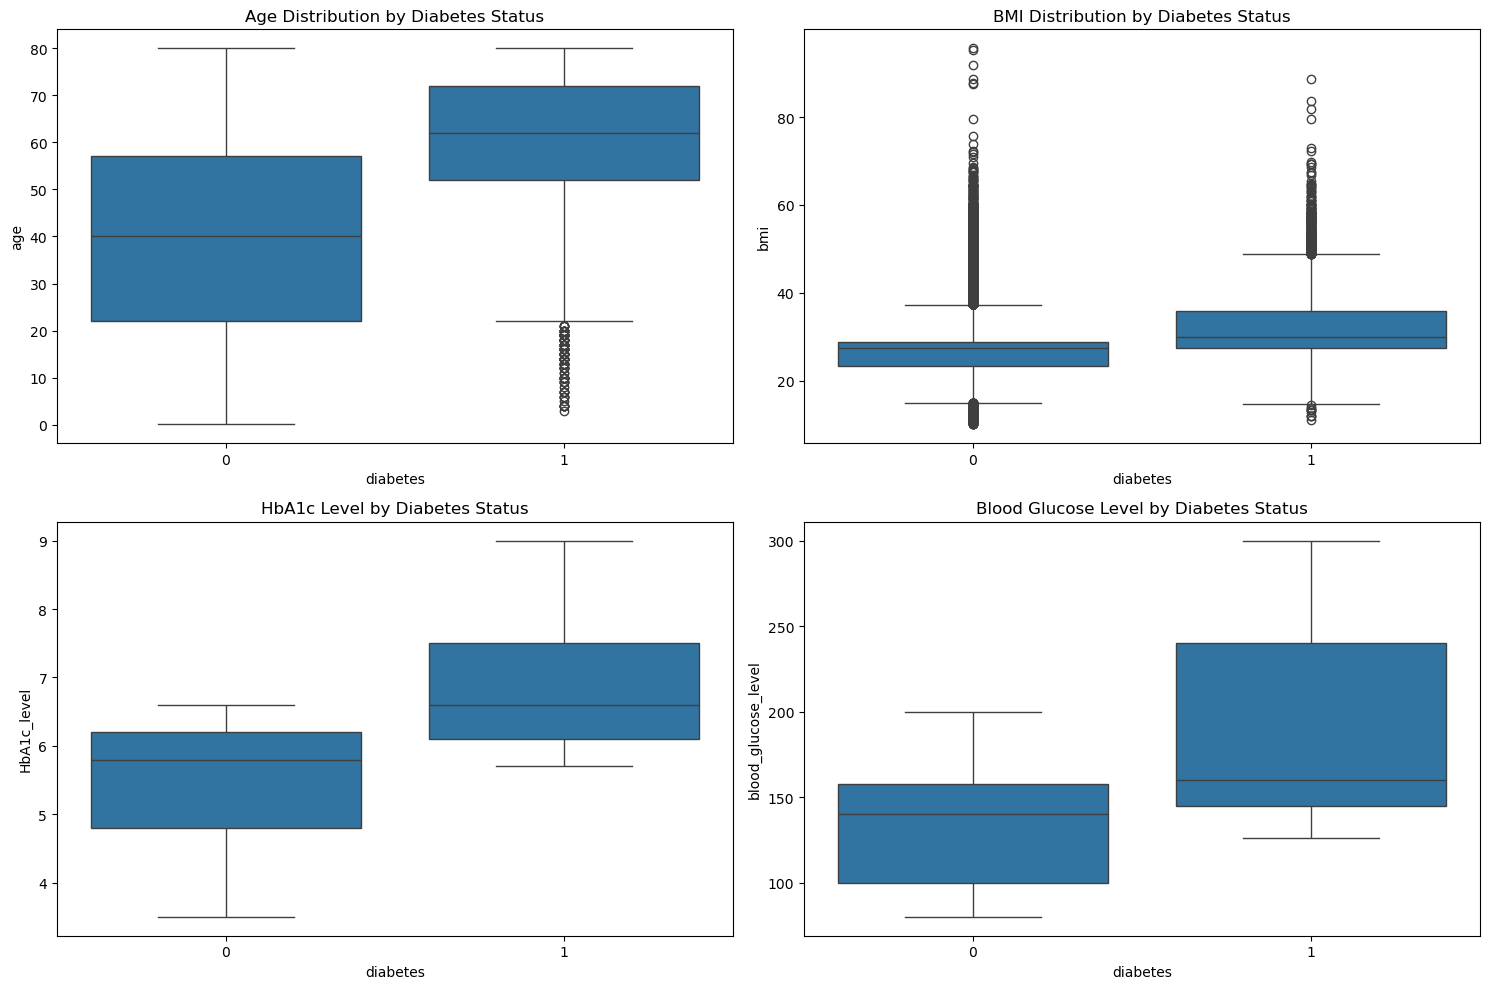

In [16]:
# Exploration of Diabetes Risk Factors
print("Key Diabetes Risk Factors from the Dataset \n")

# Summary statistics by diabetes status
risk_summary = df.groupby('diabetes').agg({
    'age': ['mean', 'median'],
    'bmi': ['mean', 'median'],
    'HbA1c_level': ['mean', 'median'],
    'blood_glucose_level': ['mean', 'median'],
    'hypertension': 'mean',
    'heart_disease': 'mean'
}).round(2)

print("Risk Factor Comparison (Diabetes vs Non-Diabetes):")
print(risk_summary)
print("Major Risk Factors Identified:")
print("""
1. HbA1c Level (Strongest)
2. Blood Glucose Level
3. Age
4. BMI (Obesity)
5. Hypertension
6. Heart Disease
7. Smoking History (moderate effect)
""")

# Visualizations of key risk factors
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
sns.boxplot(x='diabetes', y='age', data=df, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Diabetes Status')

# BMI distribution
sns.boxplot(x='diabetes', y='bmi', data=df, ax=axes[0,1])
axes[0,1].set_title('BMI Distribution by Diabetes Status')

# HbA1c distribution
sns.boxplot(x='diabetes', y='HbA1c_level', data=df, ax=axes[1,0])
axes[1,0].set_title('HbA1c Level by Diabetes Status')

# Blood Glucose distribution
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df, ax=axes[1,1])
axes[1,1].set_title('Blood Glucose Level by Diabetes Status')

plt.tight_layout()
plt.show()